In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


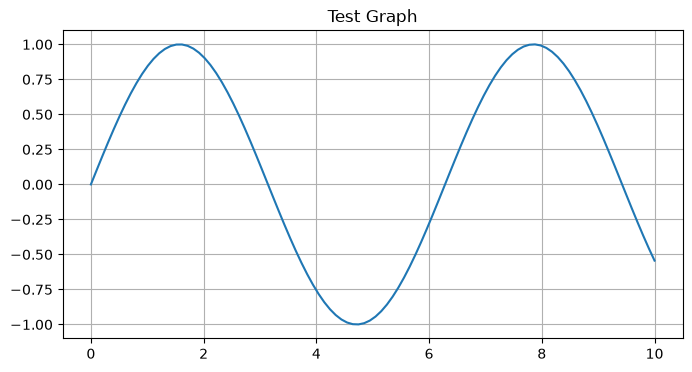

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8,4))
plt.plot(x, y)
plt.title("Test Graph")
plt.grid(True)
plt.show()

In [3]:
# ==========================================
# Import Required Libraries
# ==========================================
import numpy as np
from numpy import hstack, zeros, ones
from numpy.random import rand, randn

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# ==========================================
# Global Parameters
# ==========================================
LENGTH_INPUT = 300
LATENT_DIM = 100


# ==========================================
# Define Discriminator
# ==========================================
def define_discriminator(n_inputs=LENGTH_INPUT):

    model = Sequential(name="Discriminator")

    model.add(Input(shape=(n_inputs,)))
    model.add(Dense(300, activation='relu'))
    model.add(Dense(250, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==========================================
# Define Generator
# ==========================================
def define_generator(latent_dim=LATENT_DIM,
                     n_outputs=LENGTH_INPUT):

    model = Sequential(name="Generator")

    model.add(Input(shape=(latent_dim, 1)))
    model.add(LSTM(150))
    model.add(Dense(n_outputs, activation='linear'))

    model.compile(
        optimizer='adam',
        loss='mae',
        metrics=['mae']
    )

    return model


# ==========================================
# Define GAN
# ==========================================
def define_gan(generator, discriminator):

    discriminator.trainable = False

    model = Sequential(name="GAN")

    model.add(generator)
    model.add(discriminator)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy'
    )

    return model


# ==========================================
# Create Models
# ==========================================
discriminator = define_discriminator()

generator = define_generator()

gan_model = define_gan(generator, discriminator)


# ==========================================
# Print Model Summaries
# ==========================================
print("\nGenerator Summary")
generator.summary()

print("\nDiscriminator Summary")
discriminator.summary()

print("\nGAN Summary")
gan_model.summary()

2026-07-08 05:51:14.898180: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-08 05:51:14.898484: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 05:51:14.948384: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-08 05:51:16.144298: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-poin


Generator Summary


W0000 00:00:1783489876.645732 4087686 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150)            │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        45,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 300)            │       136,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       190,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,251 (1.25 MB)

 Trainable params: 136,500 (533.20 KB)

 Non-trainable params: 190,751 (745.12 KB)

In [4]:
# ==========================================
# Generate Real Samples
# ==========================================
def generate_real_samples(n):

    amps = np.arange(0.1, 10, 0.1)
    bias = np.arange(0.1, 10, 0.1)
    freqs = np.linspace(1, 2, 1000)

    X2 = np.linspace(-5, 5, LENGTH_INPUT)

    X1 = []

    for _ in range(n):

        noise = np.random.normal(size=len(X2))

        signal = (
            np.random.choice(amps)
            * np.sin(X2 * np.random.choice(freqs))
            + np.random.choice(bias)
            + 0.3 * noise
        )

        X1.append(signal)

    X1 = np.array(X1).reshape(n, LENGTH_INPUT)

    y = np.ones((n, 1))

    return X1, y


# ==========================================
# Generate Latent Points
# ==========================================
def generate_latent_points(latent_dim, n):

    x_input = np.random.randn(n, latent_dim)

    # Reshape for LSTM input
    x_input = x_input.reshape(n, latent_dim, 1)

    return x_input


# ==========================================
# Generate Fake Samples
# ==========================================
def generate_fake_samples(generator, latent_dim, n):

    x_input = generate_latent_points(latent_dim, n)

    X = generator.predict(x_input, verbose=0)

    y = np.zeros((n, 1))

    return X, y

In [5]:
LATENT_DIM = 100

generator = define_generator(LATENT_DIM)

X_real, y_real = generate_real_samples(5)
print(X_real.shape)
print(y_real.shape)

X_fake, y_fake = generate_fake_samples(generator, LATENT_DIM, 5)
print(X_fake.shape)
print(y_fake.shape)

(5, 300)
(5, 1)
(5, 300)
(5, 1)


In [6]:
# ==========================================
# Train the GAN
# ==========================================
def train(g_model,
          d_model,
          gan_model,
          latent_dim,
          n_epochs=10000,
          n_batch=128,
          n_eval=200):

    half_batch = n_batch // 2

    for i in range(n_epochs):

        # -----------------------------
        # Train Discriminator
        # -----------------------------

        # Real samples
        x_real, y_real = generate_real_samples(half_batch)
        d_loss_real, d_acc_real = d_model.train_on_batch(x_real, y_real)

        # Fake samples
        x_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
        d_loss_fake, d_acc_fake = d_model.train_on_batch(x_fake, y_fake)

        # -----------------------------
        # Train Generator
        # -----------------------------

        x_gan = generate_latent_points(latent_dim, n_batch)

        # Generator wants discriminator to predict "real"
        y_gan = np.ones((n_batch, 1))

        g_loss = gan_model.train_on_batch(x_gan, y_gan)

        # -----------------------------
        # Display Progress
        # -----------------------------

        if (i + 1) % n_eval == 0:

            print(f"Epoch {i+1}/{n_epochs}")
            print(f"D Loss Real : {d_loss_real:.4f}")
            print(f"D Loss Fake : {d_loss_fake:.4f}")
            print(f"Generator Loss : {g_loss:.4f}")

            pred_data, _ = generate_fake_samples(g_model, latent_dim, 1)
            real_data, _ = generate_real_samples(1)

            plt.figure(figsize=(10, 4))

            plt.plot(real_data[0],
                     '.',
                     label='Real Sample')

            plt.plot(pred_data[0],
                     '.',
                     label='Generated Sample')

            plt.title(f'Epoch {i+1}')
            plt.xlabel("Time Step")
            plt.ylabel("Amplitude")
            plt.legend()
            plt.grid(True)

            plt.show()

In [7]:
# ==========================================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam

# ==========================================================
# 2. GLOBAL PARAMETERS
# ==========================================================

LENGTH_INPUT = 300       # Length of generated signal
LATENT_DIM = 100         # Size of latent vector

# ==========================================================
# 3. DEFINE DISCRIMINATOR
# ==========================================================

def define_discriminator(n_inputs=LENGTH_INPUT):

    model = Sequential(name="Discriminator")

    model.add(Input(shape=(n_inputs,)))
    model.add(Dense(300, activation='relu'))
    model.add(Dense(250, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.0002),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# 4. DEFINE GENERATOR
# ==========================================================

def define_generator(latent_dim=LATENT_DIM,
                     n_outputs=LENGTH_INPUT):

    model = Sequential(name="Generator")

    model.add(Input(shape=(latent_dim, 1)))
    model.add(LSTM(150))
    model.add(Dense(200, activation='relu'))
    model.add(Dense(n_outputs, activation='linear'))

    return model

# ==========================================================
# 5. DEFINE GAN
# ==========================================================

def define_gan(generator, discriminator):

    discriminator.trainable = False

    model = Sequential(name="GAN")

    model.add(generator)
    model.add(discriminator)

    model.compile(
        optimizer=Adam(learning_rate=0.0002),
        loss='binary_crossentropy'
    )

    return model